<a href="https://colab.research.google.com/github/nika19du/AI-for-Developers-summer-2026-/blob/main/LangChain_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
!pip install -q langchain langchain-openai langchain-community langchain-chroma langchain-text-splitters

## Agent:
  - имаме ai model, който приема съобщения и връща съобщения. AI Models & auto regresivnite modeli са добри в да разбират и да произвеждат текст. В последствие ние ги опитомяваме на база на текста който произвеждат те да могат да си поискат изпълнението на определн инструмент.
# Model
# Tools:
  - като функция е приема аргументи и връща някакъв резултат
  - хубаво е да връща текст, заради AI Model защото модела работи предимно с текст
# Loader
  - да зареди някакво съдържание, само че зареждането на това съдържание се случва с цел популирането на някаква спомагателна система. Идеята на loaders е че зареждат документи. Тези документи дали ще се намират в нашата файлова система, в гитхъб, notion няма значение, за интеграции с всякакви външни системи. Разчитаме на интерфейсите на loaders да извлекат текстово съдържание, имаме loaders най-различни с различна цел, някой са специализирани, приличат си по своята насоченост. След като сме заредили документите, трябва да ги разпачосаме - да го разделим на чънкове и тук идва сплитъра
# Splitter:
  - има най-различни стратегии за сплитване, на първо място е RecurisiveCharacterTextSplitter - той е за случаите, в които работим с естествен текст. RecurisiveCharacterTextSplitter Чисто йерархично ще се опита да раздели текста, да запази параграфите, ще се опита да запази структурата на изреченията, няма да среже думите.
  - Length-based: примитивен подход, 1000 символа един чънк и с овърлап само че не е добър защото остават срязани думи в началото и в края и се губи смисъла
  - Document structure-based: той е за md files, разделя го структурно , така ще запазим целостта на въпроса и на отговора от md file и те ще вървят в complect -> с помощта на Split markdown - text splitter integration. Сплитва за да получим чънкове, които ще пазим във векторна база.

  **- Използваме да заредим документи !!!**
# VectorStore:
  - векторната база ни дава възможност да запишем множество документи, като всеки един от тези документи се ембедва. Тоест използваме специализиран вектор модел чрез който ние да оценим семантичното значение и да го представим като вектор т.е като списък от числа. Съответно ролята на векторната база е да може да организира всички тези вектори по интелигентен и оптимален начин и да може бързо да отговаря на query. Когато ние запишем някакво query или ai прецени че иска да търси някаква информация - ще бъде съставен нов ембединг вектор за quer-ито и векторната база трябва да може да намери чисто смислово тези вектори, които най-много се доближават до query-то
    - имаме In-memory
    - chroma
    - mongoDb
    - pinecone
** # Retriever: -> at inference time **
  - дават възможност на нашият агент да търси/извлича информация от някакъв източник - дали ще взимаме от wikipedia, arxiv, векторна база - няма значение. Въпроса е че reatreavera също зарежда текст но в контекста на нашият агент.
# Middleware:
# Checkpointer
# Store
# Graph + Node

In [63]:
# Agent: имаме ai model, който приема съобщения и връща съобщения. AI Models & auto regresivnite modeli са добри в да разбират и да произвеждат текст. В последствие ние ги опитомяваме на база на текста който произвеждат те да могат да си поискат изпълнението на определн инструмент.
# Model
# Tools
# Loader
# Splitter
# Retriever
# Middleware
# Checkpointer
# Store
# Graph + Node

In [127]:
import json

from IPython.display import Image
from google.colab import userdata
from langchain.agents import AgentState, create_agent
from langchain.tools import tool
from langchain.messages import HumanMessage
from langchain.agents.middleware.types import after_model, before_model
from langchain_core.messages import BaseMessage
from langchain_community.document_loaders import TextLoader
from langchain_core.tools import create_retriever_tool
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_openai import ChatOpenAI
from langgraph.runtime import Runtime
from langchain_chroma import Chroma
from typing import List

In [65]:
def print_conversation(messages: List[BaseMessage]) -> None:
    for message in messages:
        message.pretty_print()

In [66]:
openai_api_key = userdata.get('OPENAI_API_KEY')
openai_model = ChatOpenAI(model = "gpt-5.6-luna", api_key = openai_api_key, use_responses_api = True)

In [67]:
chroma = Chroma(collection_name = "faq", persist_directory="/content/chroma")

In [68]:
# agent = create_agent(
#     model = openai_model,
#     tools = [],
#     system_prompt = "You are a helpful customer support agent.",
#     debug = True
# )

за да се обърнем към агента трябва да извикаме **invoke** и очакваме да подадем някакъв обект / речник.
Стартирайки обръщението към нашият агент трябва да подготвим дефолтен state и agent state е обект в който имаме списък от съобщения и различните съобщения могат да бъдат AIMessage, ToolCallMessage, HumanMessage

- AIMessage е директният отговор, който ai ни е върнал

- **Всяко едно обръщение към agent.Invoke() е една отделна независима сесия, независим от предишният разговор.**

In [69]:
# exploration_response = agent.invoke(
#     input =
#     {
#         "messages": [
#             HumanMessage("Hello! My name is Nikol, nice to meet you!")
#         ]
#     }
# )

In [70]:
# print_conversation(exploration_response['messages'])

*   зареждаме файла
*   сплитваме го
* слагаме го във векторна база
* след това да пострим един retreaver, който по време на inference чрез съответен инструмент ще дадем възможност на модела да търси информация във нашият вътрешен knowledge base
<hr/>

**това е необходимо за нашата RAG идея**

**RAG**(Retrieval Augmented Generation) - зареждаме документите, вкарваме ги във векторната база и построяваме retreaver, който в същото време е инструмент чрез който агента може да получи тази информация на база на query-тата, които ще изпълнява.
<hr/>

**CAG** (Cache Augmented Generation) - е идеята, при която зареждаме съдържанието на този файл и директно го вкарваме в системният промпт, директно обогатяваме контекста на нашият агент с цялата налична информация. И тогава той ще може да я съобрази, тогава той ще може да бъде helpfull personal or customer support assistant.
  - проблема при CAG е когато документа ни стане много голям или имаме много различни документи, с различни особености няма как да влезнат в системният промпт.

In [71]:
text_loader = TextLoader(file_path="/content/FAQ.md")
splitter = MarkdownHeaderTextSplitter(headers_to_split_on = [('##', 'question')], strip_headers=False)

documents = text_loader.load()

In [72]:
documents = text_loader.load()

chunks_to_embed = []
for document in documents:
    chunks_to_embed.extend(splitter.split_text(document.page_content))

In [73]:
chunks_to_embed

[Document(metadata={'question': 'Q1. What is the warranty?'}, page_content='# Company FAQ  \n## Q1. What is the warranty?  \nThe warranty period is **24 months for individuals** and **12 months for legal entities**.  \nThe warranty does not cover mechanical damage, liquid damage, improper use, or unauthorized repairs.  \n---'),
 Document(metadata={'question': 'Q2. How do I make a warranty claim?'}, page_content='## Q2. How do I make a warranty claim?  \nYou can submit a warranty claim through the form on our website or by contacting customer support.  \nPlease provide:  \n- your order number;\n- a short description of the problem;\n- photos of the product, if relevant.  \nOur service department will review the request and respond within **2 business days**.  \n---'),
 Document(metadata={'question': 'Q3. How long does a repair take?'}, page_content='## Q3. How long does a repair take?  \nWarranty repairs may take up to **30 calendar days**.  \nIf a required spare part is unavailable, cu

In [74]:
chroma.add_documents(chunks_to_embed)

['09085c71-cc13-4a78-9009-8a34fd0bb951',
 '9f0dfcf0-684d-4fe6-b379-95ce11dfac3b',
 '0e3e8a11-8639-44ef-853b-b02d7423d5c9',
 '87d04e4b-3acc-42ae-896a-399039e79a55',
 '6c074a24-61cb-4427-a85f-18e472699db5',
 'be6d1629-4dd4-40c0-8343-5b1f85b4460b',
 '380d4b9c-a67a-426b-a36c-1b612562d257',
 '4688b9c4-2034-49f6-8d85-995fe0d05723',
 '462d4b18-9f12-4f43-94e1-c69ee8a8149f',
 '80e4173f-9ad0-4df9-8ca7-99c8b8dd1763',
 '72ac23da-65f0-48f9-b999-e05dca491a4e',
 '5214c7ba-b916-49b7-8149-58fc16b5e83f']

In [75]:
## @tool
# всеки един инструмент е json обект, който описва името на инструментите, аргументите и дава описание за самият инструмент заедно с описание за всеки един от аргументите
# def search_knowledgebase(query: str) -> str:
#     """
#     Call this tool to search the internal knowledgebase using natural language query.
#     """

#     results = chroma.similarity_search(query, k = 3)

#     return "\n\n----\n\n".join(d.page_content for d in results)
# What now?
# 1. We can implement a custom tool that accepts query, searches withing the VDB, and returns results
# 2. Transform the VDB into Retriever and than Tool

chroma_retriever = chroma.as_retriever(search_kwargs={"k":3}) # построяваме retreavara и имайки го после построяваме инструмент
search_knowledgebase = create_retriever_tool(chroma_retriever, 'search_knowledgabase', "Call this tool to search the internal knowledgebase using natural language query.", document_separator="\n\n----\n\n")

In [112]:
@tool
def my_orders() -> str:
    """
    Call this tool to retrieve all orders of the customer.
    """

    orders = [
        {"id": 13, "status": "pending"},
        {"id": 25, "status": "delivered"}
    ]

    return json.dumps(orders)

@tool
def lookup_order_details(id: int) -> str:
    """
    Call this tool to lookup additional information about a given order by its id.
    """
    details = {
        13: {
            "price": 3.14,
            "vat": 1.06,
            "products": "whole milk"
        },
        25: {
            "price": 17.89,
            "vat": 3.08,
            "products": "keyboard & mouse"
        },
    }

    result = details.get(id)
    if result is None:
        return "An order with this id was not found"

    return json.dumps(result)

In [99]:
my_orders.invoke(input="")

'[{"id": 13, "status": "pending"}, {"id": 25, "status": "delivered"}]'

In [78]:
# system_prompt_fragments = ["You are a helpful customer support agent."]
# system_prompt_fragments.extend(d.page_content for d in documents)
# system_prompt_fragments

In [138]:
@before_model
def before_model_func(state: AgentState, runtime: Runtime) -> None:
    print("Event: before_model")

@after_model
def after_model_func(state: AgentState, runtime: Runtime) -> None:
    print("Event: after_model")
    print(f"Usage: {state['messages'][-1].usage_metadata}")

In [139]:
agent = create_agent(
    model = openai_model,
    tools = [search_knowledgebase, my_orders, lookup_order_details],
    middleware = [before_model_func, after_model_func],
    system_prompt = "You are a helpful customer support agent.", # previously we did it with CAG approach - "\n\n\n".join(system_prompt_fragments), # cag
    debug = True
)

агента е конкретна реализация на граф. граф построен от бибилотеката LangGraph. LangGraph дава основата върху която стъпва LangChain.

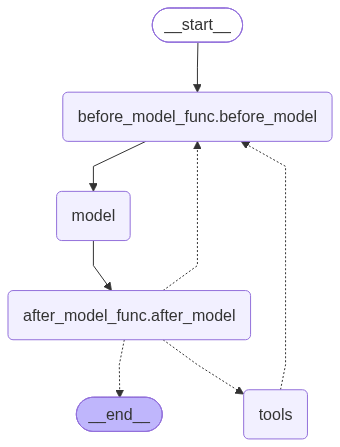

In [140]:
display(Image(agent.get_graph().draw_mermaid_png(), format="png"))

In [141]:
delivery_response = agent.invoke(
    input =
    {
        "messages": [
            HumanMessage("How long should I wait for a standard delivery? Do you offer an express option?")
        ]
    }
)

[values] {'messages': [HumanMessage(content='How long should I wait for a standard delivery? Do you offer an express option?', additional_kwargs={}, response_metadata={}, id='2368488a-4051-4424-9104-dd5e848a22d1')]}
Event: before_model
[updates] {'before_model_func.before_model': None}
[updates] {'model': {'messages': [AIMessage(content=[{'id': 'rs_0f4a474325b07785006a88cbf5cd7087d2b1d320963824de1a', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqiMv2iUxI3C6E8KLZ3iSLjs9W_rfPbiInklRHWCHz9NqnTqBfNN6G_lmPJ5L24wB7sQBcP1o1ns2uPx_LoPJ4hYzo58vl4mEjj5rJkJtwMcd9lYl115NXLr0taPwGKlt5ddlOJXsIh1Pah-ALj6y1xdrODtUGjJ2sHlTWb8pA7I0Phj_xkc-u3nyyUgVrvyS1PB_YklmYja0ADvWbfQyNCg99bjtRr2Ik-mb0_NeXiDLELNufn5prZWpboECJbsP5e7ozSaudr_ZFVKMSA9Q2bTQQSBuJTuOOFTOmkymDi3Ncg6tkvV0POMuuDlfbJCmA5IO7dqp0fI9edBvukj2Y1LZ1IFqqdn1k3S-OpIgxaDml3UJfYyO_h9ozSfFBvhl0XjaCgAkiJ2MC-zWLknm1unzhxofKZQp6MeC_SGQ7cxLSOCGJK0x-Crq00esaz4389Mfn54uuCKclUMgI6OmVxjCi_qFD5yTsWaiUeGaCnDjr0UI1LGwOVo76EQ06vPt5RlV

In [142]:
print_conversation(delivery_response['messages'])

================================ Human Message =================================

How long should I wait for a standard delivery? Do you offer an express option?
================================== Ai Message ==================================

[{'id': 'rs_0f4a474325b07785006a88cbf5cd7087d2b1d320963824de1a', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqiMv2iUxI3C6E8KLZ3iSLjs9W_rfPbiInklRHWCHz9NqnTqBfNN6G_lmPJ5L24wB7sQBcP1o1ns2uPx_LoPJ4hYzo58vl4mEjj5rJkJtwMcd9lYl115NXLr0taPwGKlt5ddlOJXsIh1Pah-ALj6y1xdrODtUGjJ2sHlTWb8pA7I0Phj_xkc-u3nyyUgVrvyS1PB_YklmYja0ADvWbfQyNCg99bjtRr2Ik-mb0_NeXiDLELNufn5prZWpboECJbsP5e7ozSaudr_ZFVKMSA9Q2bTQQSBuJTuOOFTOmkymDi3Ncg6tkvV0POMuuDlfbJCmA5IO7dqp0fI9edBvukj2Y1LZ1IFqqdn1k3S-OpIgxaDml3UJfYyO_h9ozSfFBvhl0XjaCgAkiJ2MC-zWLknm1unzhxofKZQp6MeC_SGQ7cxLSOCGJK0x-Crq00esaz4389Mfn54uuCKclUMgI6OmVxjCi_qFD5yTsWaiUeGaCnDjr0UI1LGwOVo76EQ06vPt5RlVC9vT6yfxeUeZ6e422c_2tyKj_3BKG5VCnIE-oVG9SKXJiQtwOR66dCFebZHXq7wrPRBUtli2kg0BPpMqjv4Gmnjypn-MfKs

In [143]:
my_orders_response = agent.invoke(
    input =
    {
        "messages": [
            HumanMessage("Can you give me a detailed information about my order?")
        ]
    }
)

[values] {'messages': [HumanMessage(content='Can you give me a detailed information about my order?', additional_kwargs={}, response_metadata={}, id='2896cd85-4b81-4ead-b99b-a3375075f0f8')]}
Event: before_model
[updates] {'before_model_func.before_model': None}
[updates] {'model': {'messages': [AIMessage(content=[{'id': 'rs_0df1c82d678d1d28006a88cc5dca9487d2abbf14102a538ca0', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqiMxeOPVbTBPhkJjgC9sF0zVQriX9Uuo7uJLLJ0WZF6KoH8Q1JfTJMF-d2xncmCjD0THJiNL5Kwa53RtU54smdTILsLRoq158Kb5uBcN6gcaaKZbN_IThuhq7CaCHbvafmdjl9yIJZRxI7ldAPu-1N9ah34ttI2ogTElTkrRQ1EaCtiLb6beh8eSJtfGkMsFOnxDhQmCN8mHfDtjmlyCRrIFpuP0zO2NRuyFSYizYlRDN7d5Eibn3byQxykhBvOiu6cTLkyj-gMtdpTqPrOhOQZQyHTCDYPA-CGgrhADY7pVzFTihOJBY1nR7NFRsI95taMDI0wQiy4-zLJNPw_H5mHjqPT-Qo69vW0lJHo0SAcsPJCjHrFJFybmDtBJg5h989ts7WlEBx8b6U-1da_SWTnK8gFgwoscgHfUdZ9Vd4bF2j4lHRhKqKHAh9VqdBPD8cqWA0Y1WdGz2lvD6BUon-m5h_5pnYpBlnConRX-jXifBhmHzo0gnlv4nf9rSFHvuMEJ9dh_z_TOYYdLTtmSeJ2nHceIa

In [144]:
print_conversation(my_orders_response['messages'])

================================ Human Message =================================

Can you give me a detailed information about my order?
================================== Ai Message ==================================

[{'id': 'rs_0df1c82d678d1d28006a88cc5dca9487d2abbf14102a538ca0', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqiMxeOPVbTBPhkJjgC9sF0zVQriX9Uuo7uJLLJ0WZF6KoH8Q1JfTJMF-d2xncmCjD0THJiNL5Kwa53RtU54smdTILsLRoq158Kb5uBcN6gcaaKZbN_IThuhq7CaCHbvafmdjl9yIJZRxI7ldAPu-1N9ah34ttI2ogTElTkrRQ1EaCtiLb6beh8eSJtfGkMsFOnxDhQmCN8mHfDtjmlyCRrIFpuP0zO2NRuyFSYizYlRDN7d5Eibn3byQxykhBvOiu6cTLkyj-gMtdpTqPrOhOQZQyHTCDYPA-CGgrhADY7pVzFTihOJBY1nR7NFRsI95taMDI0wQiy4-zLJNPw_H5mHjqPT-Qo69vW0lJHo0SAcsPJCjHrFJFybmDtBJg5h989ts7WlEBx8b6U-1da_SWTnK8gFgwoscgHfUdZ9Vd4bF2j4lHRhKqKHAh9VqdBPD8cqWA0Y1WdGz2lvD6BUon-m5h_5pnYpBlnConRX-jXifBhmHzo0gnlv4nf9rSFHvuMEJ9dh_z_TOYYdLTtmSeJ2nHceIa0dfxwChYNVGnuJ5m_QkdVcnjx4LdbOxhyF7KqmBFYmV0bv1iOqlnnVI1bqob8EDxf-ibZ-2EqMfA3N-1Rums6G7pHevwDTy